Загружены данные с синусоидальным трендом. Количество точек: 100
Загружены данные с линейным трендом. Количество точек: 10


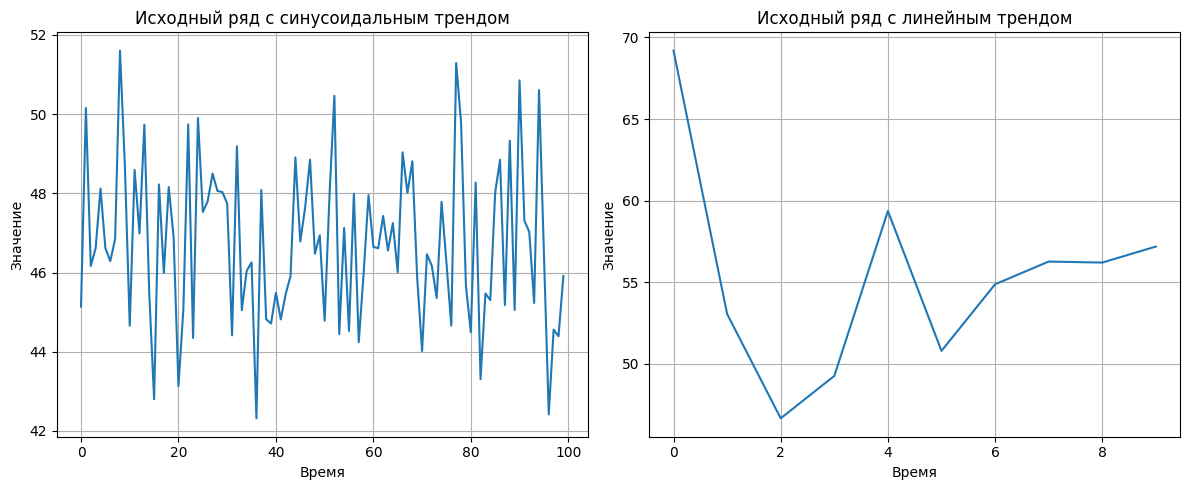

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sin_data = pd.read_csv('data/1.txt', header=None, names=['value'])
linear_data = pd.read_csv('data/2.txt', header=None, names=['value'])

# Добавление временного индекса
sin_data['time'] = range(len(sin_data))
linear_data['time'] = range(len(linear_data))

print(f"Загружены данные с синусоидальным трендом. Количество точек: {len(sin_data)}")
print(f"Загружены данные с линейным трендом. Количество точек: {len(linear_data)}")

# Построение исходных данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sin_data['time'], sin_data['value'])
plt.title('Исходный ряд с синусоидальным трендом')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(linear_data['time'], linear_data['value'])
plt.title('Исходный ряд с линейным трендом')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson
import math


# Вспомогательные функции для статистических тестов
def ljung_box_statistic(residuals, lag=5):
    n = len(residuals)
    if n <= lag:
        return float('inf')
    
    acf_values = acf(residuals, nlags=lag, fft=False)
    q_stat = 0
    for k in range(1, lag + 1):
        q_stat += (acf_values[k] ** 2) / (n - k)
    q_stat *= n * (n + 2)
    
    return q_stat

def durbin_watson_test(residuals, m=1):
    n = len(residuals)
    dw_stat = durbin_watson(residuals)
    table_10 ={
        1: (0.879, 1.320),
        2: (0.697, 1.641),
        3: (0.525, 2.016),
        4: (0.356, 2.414),
        5: (0.243, 2.822),
        6: (0.15, 3),
        7: (0.1, 3.5),  
        }
    table_100 ={
        1: (1.583, 1.641),
        2: (1.554, 1.672),
        3: (1.525, 1.703),
        4: (1.494, 1.735),
        5: (1.464, 1.768),
        6: (1.433, 1.802),
        7: (1.401, 1.837),
        }
    if n == 10:
        dL, dU = table_10[m]
    else:
        dL, dU = table_100[m]
    
    # Вычисление d'
    d_prime = dw_stat if dw_stat <= 2 else 4 - dw_stat
    
    # Интерпретация результата
    if d_prime <= dL:
        result = "есть положительная автокорреляция"
    elif d_prime >= dU:
        result = "автокорреляция отсутствует"
    else:
        result = "зона неопределенности"
    
    return dw_stat, result

Оптимальное значение m для SMA: 7
Результаты для разных значений m:
  m=1, окно=3, Q-статистика=55.1791
  m=2, окно=5, Q-статистика=26.3588
  m=3, окно=7, Q-статистика=18.3776
  m=4, окно=9, Q-статистика=15.4695
  m=5, окно=11, Q-статистика=6.4619
  m=6, окно=13, Q-статистика=4.8724
  m=7, окно=15, Q-статистика=3.2242
Тест Дарбина-Уотсона: статистика=2.2945, результат: зона неопределенности


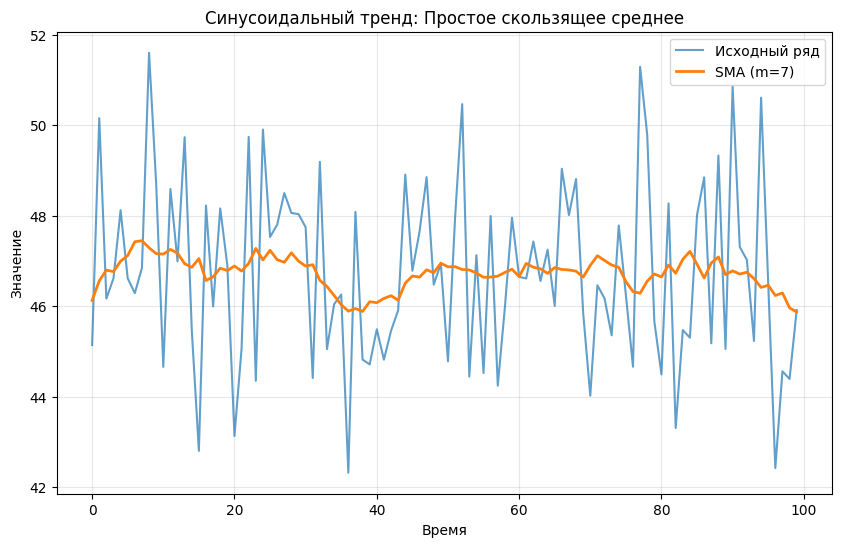

In [24]:
# Анализ синусоидального тренда - SMA

# Поиск оптимального размера окна для SMA
optimal_m_sma_sin = None
min_q_sma_sin = float('inf')
results_sma_sin = []
m_values = [1, 2, 3, 4, 5, 6, 7]

for m in m_values:
    window_size = 2 * m + 1
    # Применяем padding для сохранения размера ряда
    padded_data = np.pad(sin_data['value'].values, (m, m), mode='edge')
    smoothed = np.convolve(padded_data, np.ones(window_size) / window_size, mode='valid')
    
    residuals = sin_data['value'].values - smoothed
    q_stat = ljung_box_statistic(residuals, lag=5)
    
    results_sma_sin.append((m, window_size, q_stat))
    if q_stat < min_q_sma_sin:
        min_q_sma_sin = q_stat
        optimal_m_sma_sin = m

print(f"Оптимальное значение m для SMA: {optimal_m_sma_sin}")
print("Результаты для разных значений m:")
for m, window, q in results_sma_sin:
    print(f"  m={m}, окно={window}, Q-статистика={q:.4f}")

# Построение сглаженного ряда с оптимальным параметром
optimal_window_sma_sin = 2 * optimal_m_sma_sin + 1
padded_data = np.pad(sin_data['value'].values, (optimal_m_sma_sin, optimal_m_sma_sin), mode='edge')
smoothed_sma_sin = np.convolve(padded_data, np.ones(optimal_window_sma_sin) / optimal_window_sma_sin, mode='valid')
residuals_sma_sin = sin_data['value'].values - smoothed_sma_sin
dw_sma_sin, result_sma_sin = durbin_watson_test(residuals_sma_sin, m=optimal_m_sma_sin)
print(f"Тест Дарбина-Уотсона: статистика={dw_sma_sin:.4f}, результат: {result_sma_sin}")

# Построение графика для SMA
plt.figure(figsize=(10, 6))
plt.plot(sin_data['time'], sin_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(sin_data['time'], smoothed_sma_sin, label=f'SMA (m={optimal_m_sma_sin})', linewidth=2)
plt.title('Синусоидальный тренд: Простое скользящее среднее')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Оптимальное значение m для SMA: 7
Результаты для разных значений m:
  m=1, окно=3, Q-статистика=6.4477
  m=2, окно=5, Q-статистика=6.8869
  m=3, окно=7, Q-статистика=4.6450
  m=4, окно=9, Q-статистика=2.9613
  m=5, окно=11, Q-статистика=3.0502
  m=6, окно=13, Q-статистика=3.1238
  m=7, окно=15, Q-статистика=2.8894
Тест Дарбина-Уотсона: статистика=1.0927, результат: зона неопределенности


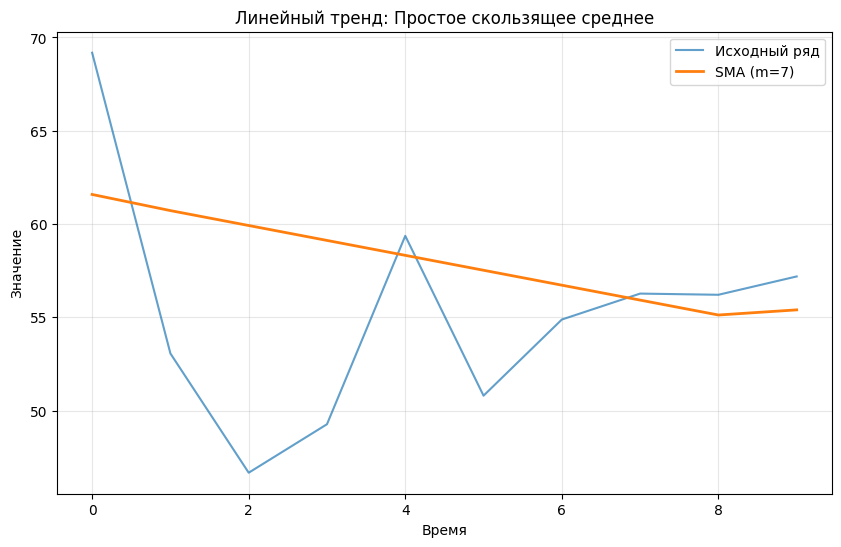

In [25]:
# Анализ линейного тренда - SMA
# Поиск оптимального размера окна для SMA
optimal_m_sma_lin = None
min_q_sma_lin = float('inf')
results_sma_lin = []

for m in m_values:
    window_size = 2 * m + 1
    padded_data = np.pad(linear_data['value'].values, (m, m), mode='edge')
    smoothed = np.convolve(padded_data, np.ones(window_size) / window_size, mode='valid')
    
    residuals = linear_data['value'].values - smoothed
    q_stat = ljung_box_statistic(residuals, lag=5)
    
    results_sma_lin.append((m, window_size, q_stat))
    if q_stat < min_q_sma_lin:
        min_q_sma_lin = q_stat
        optimal_m_sma_lin = m

print(f"Оптимальное значение m для SMA: {optimal_m_sma_lin}")
print("Результаты для разных значений m:")
for m, window, q in results_sma_lin:
    print(f"  m={m}, окно={window}, Q-статистика={q:.4f}")

# Построение сглаженного ряда с оптимальным параметром
optimal_window_sma_lin = 2 * optimal_m_sma_lin + 1
padded_data = np.pad(linear_data['value'].values, (optimal_m_sma_lin, optimal_m_sma_lin), mode='edge')
smoothed_sma_lin = np.convolve(padded_data, np.ones(optimal_window_sma_lin) / optimal_window_sma_lin, mode='valid')
residuals_sma_lin = linear_data['value'].values - smoothed_sma_lin
dw_sma_lin, result_sma_lin = durbin_watson_test(residuals_sma_lin,m=optimal_m_sma_lin)
print(f"Тест Дарбина-Уотсона: статистика={dw_sma_lin:.4f}, результат: {result_sma_lin}")

# Построение графика для SMA
plt.figure(figsize=(10, 6))
plt.plot(linear_data['time'], linear_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(linear_data['time'], smoothed_sma_lin, label=f'SMA (m={optimal_m_sma_lin})', linewidth=2)
plt.title('Линейный тренд: Простое скользящее среднее')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


2. Взвешенное скользящее среднее (WMA)
Оптимальное значение m для WMA: 7
Результаты для разных значений m:
  m=1, окно=3, Q-статистика=55.1791
  m=2, окно=5, Q-статистика=26.3905
  m=3, окно=7, Q-статистика=19.2400
  m=4, окно=9, Q-статистика=18.0728
  m=5, окно=11, Q-статистика=13.0101
  m=6, окно=13, Q-статистика=12.2558
  m=7, окно=15, Q-статистика=11.3258
Тест Дарбина-Уотсона: статистика=2.5774, результат: зона неопределенности


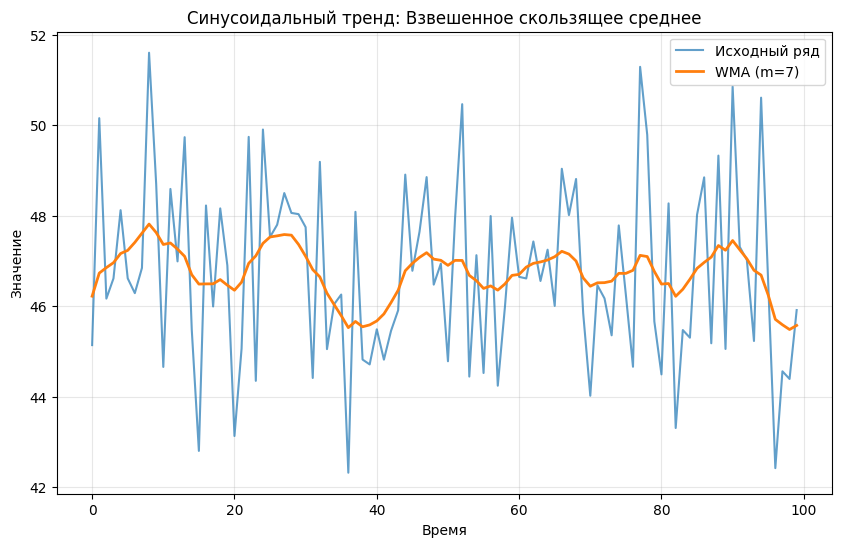

In [26]:
# Блок 5: Анализ синусоидального тренда - WMA
print("\n2. Взвешенное скользящее среднее (WMA)")

# Поиск оптимального размера окна для WMA
optimal_m_wma_sin = None
min_q_wma_sin = float('inf')
results_wma_sin = []
epsilon = 0.3

for m in m_values:
    window_size = 2 * m + 1
    # Создаем веса по экспоненциальной функции
    weights = np.array([math.exp(-epsilon * abs(i)) for i in range(-m, m + 1)])
    weights = weights / np.sum(weights)  # Нормализация весов
    
    padded_data = np.pad(sin_data['value'].values, (m, m), mode='edge')
    smoothed = np.convolve(padded_data, weights, mode='valid')
    
    residuals = sin_data['value'].values - smoothed
    q_stat = ljung_box_statistic(residuals, lag=5)
    
    results_wma_sin.append((m, window_size, q_stat))
    if q_stat < min_q_wma_sin:
        min_q_wma_sin = q_stat
        optimal_m_wma_sin = m

print(f"Оптимальное значение m для WMA: {optimal_m_wma_sin}")
print("Результаты для разных значений m:")
for m, window, q in results_wma_sin:
    print(f"  m={m}, окно={window}, Q-статистика={q:.4f}")

# Построение сглаженного ряда с оптимальным параметром
optimal_window_wma_sin = 2 * optimal_m_wma_sin + 1
weights = np.array([math.exp(-epsilon * abs(i)) for i in range(-optimal_m_wma_sin, optimal_m_wma_sin + 1)])
weights = weights / np.sum(weights)

padded_data = np.pad(sin_data['value'].values, (optimal_m_wma_sin, optimal_m_wma_sin), mode='edge')
smoothed_wma_sin = np.convolve(padded_data, weights, mode='valid')
residuals_wma_sin = sin_data['value'].values - smoothed_wma_sin
dw_wma_sin, result_wma_sin = durbin_watson_test(residuals_wma_sin, m=optimal_m_wma_sin)
print(f"Тест Дарбина-Уотсона: статистика={dw_wma_sin:.4f}, результат: {result_wma_sin}")

# Построение графика для WMA
plt.figure(figsize=(10, 6))
plt.plot(sin_data['time'], sin_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(sin_data['time'], smoothed_wma_sin, label=f'WMA (m={optimal_m_wma_sin})', linewidth=2)
plt.title('Синусоидальный тренд: Взвешенное скользящее среднее')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


2. Взвешенное скользящее среднее (WMA)
Оптимальное значение m для WMA: 7
Результаты для разных значений m:
  m=1, окно=3, Q-статистика=6.4477
  m=2, окно=5, Q-статистика=6.5248
  m=3, окно=7, Q-статистика=4.9019
  m=4, окно=9, Q-статистика=3.5490
  m=5, окно=11, Q-статистика=3.3187
  m=6, окно=13, Q-статистика=3.2437
  m=7, окно=15, Q-статистика=3.1458
Тест Дарбина-Уотсона: статистика=1.4289, результат: зона неопределенности


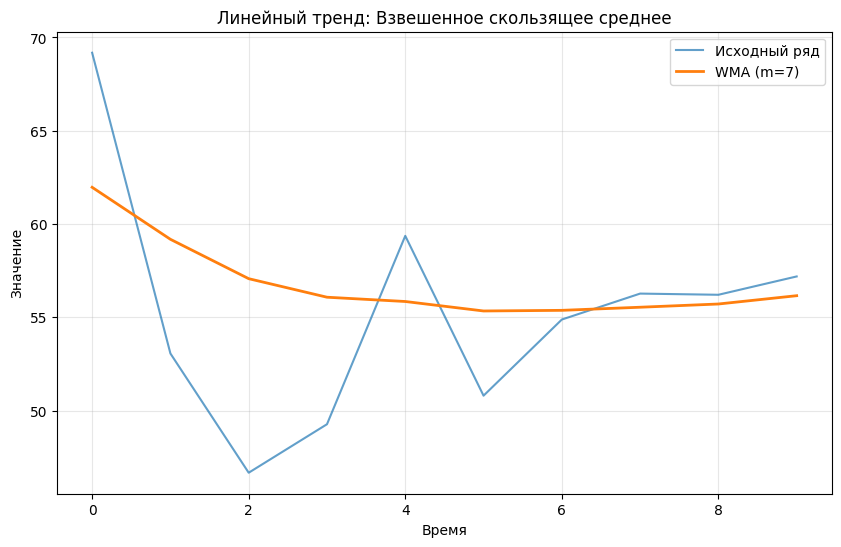

In [27]:
# Блок 9: Анализ линейного тренда - WMA
print("\n2. Взвешенное скользящее среднее (WMA)")

# Поиск оптимального размера окна для WMA
optimal_m_wma_lin = None
min_q_wma_lin = float('inf')
results_wma_lin = []

for m in m_values:
    window_size = 2 * m + 1
    weights = np.array([math.exp(-epsilon * abs(i)) for i in range(-m, m + 1)])
    weights = weights / np.sum(weights)
    
    padded_data = np.pad(linear_data['value'].values, (m, m), mode='edge')
    smoothed = np.convolve(padded_data, weights, mode='valid')
    
    residuals = linear_data['value'].values - smoothed
    q_stat = ljung_box_statistic(residuals, lag=5)
    
    results_wma_lin.append((m, window_size, q_stat))
    if q_stat < min_q_wma_lin:
        min_q_wma_lin = q_stat
        optimal_m_wma_lin = m

print(f"Оптимальное значение m для WMA: {optimal_m_wma_lin}")
print("Результаты для разных значений m:")
for m, window, q in results_wma_lin:
    print(f"  m={m}, окно={window}, Q-статистика={q:.4f}")

# Построение сглаженного ряда с оптимальным параметром
optimal_window_wma_lin = 2 * optimal_m_wma_lin + 1
weights = np.array([math.exp(-epsilon * abs(i)) for i in range(-optimal_m_wma_lin, optimal_m_wma_lin + 1)])
weights = weights / np.sum(weights)

padded_data = np.pad(linear_data['value'].values, (optimal_m_wma_lin, optimal_m_wma_lin), mode='edge')
smoothed_wma_lin = np.convolve(padded_data, weights, mode='valid')
residuals_wma_lin = linear_data['value'].values - smoothed_wma_lin
dw_wma_lin, result_wma_lin = durbin_watson_test(residuals_wma_lin, m=optimal_m_wma_lin)
print(f"Тест Дарбина-Уотсона: статистика={dw_wma_lin:.4f}, результат: {result_wma_lin}")

# Построение графика для WMA
plt.figure(figsize=(10, 6))
plt.plot(linear_data['time'], linear_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(linear_data['time'], smoothed_wma_lin, label=f'WMA (m={optimal_m_wma_lin})', linewidth=2)
plt.title('Линейный тренд: Взвешенное скользящее среднее')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# Блок 6: Анализ синусоидального тренда - EMA
print("\n3. Экспоненциальное сглаживание (EMA)")

# Поиск оптимального параметра alpha для EMA
optimal_alpha_ema_sin = None
min_q_ema_sin = float('inf')
results_ema_sin = []
alpha_values = np.arange(0.1, 1.0, 0.1)

for alpha in alpha_values:
    smoothed = np.zeros(len(sin_data))
    smoothed[0] = sin_data['value'].values[0]  # Начальное значение
    
    for t in range(1, len(sin_data)):
        smoothed[t] = alpha * sin_data['value'].values[t] + (1 - alpha) * smoothed[t-1]
    
    residuals = sin_data['value'].values - smoothed
    q_stat = ljung_box_statistic(residuals, lag=5)
    
    results_ema_sin.append((alpha, q_stat))
    if q_stat < min_q_ema_sin:
        min_q_ema_sin = q_stat
        optimal_alpha_ema_sin = alpha

print(f"Оптимальное значение alpha для EMA: {optimal_alpha_ema_sin:.1f}")
print("Результаты для разных значений alpha:")
for alpha, q in results_ema_sin:
    print(f"  alpha={alpha:.1f}, Q-статистика={q:.4f}")

# Построение сглаженного ряда с оптимальным параметром
smoothed_ema_sin = np.zeros(len(sin_data))
smoothed_ema_sin[0] = sin_data['value'].values[0]

for t in range(1, len(sin_data)):
    smoothed_ema_sin[t] = optimal_alpha_ema_sin * sin_data['value'].values[t] + (1 - optimal_alpha_ema_sin) * smoothed_ema_sin[t-1]

residuals_ema_sin = sin_data['value'].values - smoothed_ema_sin
dw_ema_sin, result_ema_sin = durbin_watson_test(residuals_ema_sin, m=optimal_alpha_ema_sin)
print(f"Тест Дарбина-Уотсона: статистика={dw_ema_sin:.4f}, результат: {result_ema_sin}")

# Построение графика для EMA
plt.figure(figsize=(10, 6))
plt.plot(sin_data['time'], sin_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(sin_data['time'], smoothed_ema_sin, label=f'EMA (alpha={optimal_alpha_ema_sin:.1f})', linewidth=2)
plt.title('Синусоидальный тренд: Экспоненциальное сглаживание')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


3. Экспоненциальное сглаживание (EMA)
Оптимальное значение alpha для EMA: 0.1
Результаты для разных значений alpha:
  alpha=0.1, Q-статистика=1.9337
  alpha=0.2, Q-статистика=2.9631
  alpha=0.3, Q-статистика=5.7619
  alpha=0.4, Q-статистика=9.2551
  alpha=0.5, Q-статистика=12.8597
  alpha=0.6, Q-статистика=16.4164
  alpha=0.7, Q-статистика=20.0092
  alpha=0.8, Q-статистика=23.8288
  alpha=0.9, Q-статистика=28.0997


KeyError: np.float64(0.1)

In [ ]:
# Блок 10: Анализ линейного тренда - EMA
print("\n3. Экспоненциальное сглаживание (EMA)")

# Поиск оптимального параметра alpha для EMA
optimal_alpha_ema_lin = None
min_q_ema_lin = float('inf')
results_ema_lin = []

for alpha in alpha_values:
    smoothed = np.zeros(len(linear_data))
    smoothed[0] = linear_data['value'].values[0]
    
    for t in range(1, len(linear_data)):
        smoothed[t] = alpha * linear_data['value'].values[t] + (1 - alpha) * smoothed[t-1]
    
    residuals = linear_data['value'].values - smoothed
    q_stat = ljung_box_statistic(residuals, lag=5)
    
    results_ema_lin.append((alpha, q_stat))
    if q_stat < min_q_ema_lin:
        min_q_ema_lin = q_stat
        optimal_alpha_ema_lin = alpha

print(f"Оптимальное значение alpha для EMA: {optimal_alpha_ema_lin:.1f}")
print("Результаты для разных значений alpha:")
for alpha, q in results_ema_lin:
    print(f"  alpha={alpha:.1f}, Q-статистика={q:.4f}")

# Построение сглаженного ряда с оптимальным параметром
smoothed_ema_lin = np.zeros(len(linear_data))
smoothed_ema_lin[0] = linear_data['value'].values[0]

for t in range(1, len(linear_data)):
    smoothed_ema_lin[t] = optimal_alpha_ema_lin * linear_data['value'].values[t] + (1 - optimal_alpha_ema_lin) * smoothed_ema_lin[t-1]

residuals_ema_lin = linear_data['value'].values - smoothed_ema_lin
dw_ema_lin, result_ema_lin = durbin_watson_test(residuals_ema_lin, m=optimal_alpha_ema_lin)
print(f"Тест Дарбина-Уотсона: статистика={dw_ema_lin:.4f}, результат: {result_ema_lin}")

# Построение графика для EMA
plt.figure(figsize=(10, 6))
plt.plot(linear_data['time'], linear_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(linear_data['time'], smoothed_ema_lin, label=f'EMA (alpha={optimal_alpha_ema_lin:.1f})', linewidth=2)
plt.title('Линейный тренд: Экспоненциальное сглаживание')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Блок 7: Анализ синусоидального тренда - DEMA
print("\n4. Двойное экспоненциальное сглаживание (DEMA)")

# Поиск оптимальных параметров alpha и gamma для DEMA
optimal_alpha_dema_sin = None
optimal_gamma_dema_sin = None
min_q_dema_sin = float('inf')
results_dema_sin = []
gamma_values = np.arange(0.1, 1.0, 0.1)

for alpha in alpha_values:
    for gamma in gamma_values:
        smoothed = np.zeros(len(sin_data))
        trend = np.zeros(len(sin_data))
        
        # Начальные значения
        smoothed[0] = sin_data['value'].values[0]
        if len(sin_data) > 1:
            trend[0] = sin_data['value'].values[1] - sin_data['value'].values[0]
        else:
            trend[0] = 0
        
        for t in range(1, len(sin_data)):
            smoothed[t] = alpha * sin_data['value'].values[t] + (1 - alpha) * (smoothed[t-1] + trend[t-1])
            trend[t] = gamma * (smoothed[t] - smoothed[t-1]) + (1 - gamma) * trend[t-1]
        
        residuals = sin_data['value'].values - smoothed
        q_stat = ljung_box_statistic(residuals, lag=5)
        
        results_dema_sin.append((alpha, gamma, q_stat))
        if q_stat < min_q_dema_sin:
            min_q_dema_sin = q_stat
            optimal_alpha_dema_sin = alpha
            optimal_gamma_dema_sin = gamma

print(f"Оптимальные значения для DEMA: alpha={optimal_alpha_dema_sin:.1f}, gamma={optimal_gamma_dema_sin:.1f}")
print(f"Минимальная Q-статистика: {min_q_dema_sin:.4f}")

# Построение сглаженного ряда с оптимальными параметрами
smoothed_dema_sin = np.zeros(len(sin_data))
trend_dema_sin = np.zeros(len(sin_data))

smoothed_dema_sin[0] = sin_data['value'].values[0]
if len(sin_data) > 1:
    trend_dema_sin[0] = sin_data['value'].values[1] - sin_data['value'].values[0]
else:
    trend_dema_sin[0] = 0

for t in range(1, len(sin_data)):
    smoothed_dema_sin[t] = optimal_alpha_dema_sin * sin_data['value'].values[t] + (1 - optimal_alpha_dema_sin) * (smoothed_dema_sin[t-1] + trend_dema_sin[t-1])
    trend_dema_sin[t] = optimal_gamma_dema_sin * (smoothed_dema_sin[t] - smoothed_dema_sin[t-1]) + (1 - optimal_gamma_dema_sin) * trend_dema_sin[t-1]

residuals_dema_sin = sin_data['value'].values - smoothed_dema_sin
dw_dema_sin, result_dema_sin = durbin_watson_test(residuals_dema_sin, m=optimal_alpha_dema_sin)
print(f"Тест Дарбина-Уотсона: статистика={dw_dema_sin:.4f}, результат: {result_dema_sin}")

# Построение графика для DEMA
plt.figure(figsize=(10, 6))
plt.plot(sin_data['time'], sin_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(sin_data['time'], smoothed_dema_sin, label=f'DEMA (alpha={optimal_alpha_dema_sin:.1f}, gamma={optimal_gamma_dema_sin:.1f})', linewidth=2)
plt.title('Синусоидальный тренд: Двойное экспоненциальное сглаживание')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Блок 11: Анализ линейного тренда - DEMA
print("\n4. Двойное экспоненциальное сглаживание (DEMA)")

# Поиск оптимальных параметров alpha и gamma для DEMA
optimal_alpha_dema_lin = None
optimal_gamma_dema_lin = None
min_q_dema_lin = float('inf')

for alpha in alpha_values:
    for gamma in gamma_values:
        smoothed = np.zeros(len(linear_data))
        trend = np.zeros(len(linear_data))
        
        smoothed[0] = linear_data['value'].values[0]
        if len(linear_data) > 1:
            trend[0] = linear_data['value'].values[1] - linear_data['value'].values[0]
        else:
            trend[0] = 0
        
        for t in range(1, len(linear_data)):
            smoothed[t] = alpha * linear_data['value'].values[t] + (1 - alpha) * (smoothed[t-1] + trend[t-1])
            trend[t] = gamma * (smoothed[t] - smoothed[t-1]) + (1 - gamma) * trend[t-1]
        
        residuals = linear_data['value'].values - smoothed
        q_stat = ljung_box_statistic(residuals, lag=5)
        
        if q_stat < min_q_dema_lin:
            min_q_dema_lin = q_stat
            optimal_alpha_dema_lin = alpha
            optimal_gamma_dema_lin = gamma

print(f"Оптимальные значения для DEMA: alpha={optimal_alpha_dema_lin:.1f}, gamma={optimal_gamma_dema_lin:.1f}")
print(f"Минимальная Q-статистика: {min_q_dema_lin:.4f}")

# Построение сглаженного ряда с оптимальными параметрами
smoothed_dema_lin = np.zeros(len(linear_data))
trend_dema_lin = np.zeros(len(linear_data))

smoothed_dema_lin[0] = linear_data['value'].values[0]
if len(linear_data) > 1:
    trend_dema_lin[0] = linear_data['value'].values[1] - linear_data['value'].values[0]
else:
    trend_dema_lin[0] = 0

for t in range(1, len(linear_data)):
    smoothed_dema_lin[t] = optimal_alpha_dema_lin * linear_data['value'].values[t] + (1 - optimal_alpha_dema_lin) * (smoothed_dema_lin[t-1] + trend_dema_lin[t-1])
    trend_dema_lin[t] = optimal_gamma_dema_lin * (smoothed_dema_lin[t] - smoothed_dema_lin[t-1]) + (1 - optimal_gamma_dema_lin) * trend_dema_lin[t-1]

residuals_dema_lin = linear_data['value'].values - smoothed_dema_lin
dw_dema_lin, result_dema_lin = durbin_watson_test(residuals_dema_lin)
print(f"Тест Дарбина-Уотсона: статистика={dw_dema_lin:.4f}, результат: {result_dema_lin}")

# Построение графика для DEMA
plt.figure(figsize=(10, 6))
plt.plot(linear_data['time'], linear_data['value'], label='Исходный ряд', alpha=0.7)
plt.plot(linear_data['time'], smoothed_dema_lin, label=f'DEMA (alpha={optimal_alpha_dema_lin:.1f}, gamma={optimal_gamma_dema_lin:.1f})', linewidth=2)
plt.title('Линейный тренд: Двойное экспоненциальное сглаживание')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()